# Lab - NLP Week 8

## Lab Summary:

In this lab we will be discussing about Neural Networks.
## Lab Goal:
Upon completion of this lab, the student should be able to:
<ul>
    <li> design neural networks and use them for simple applications </li>
    
</ul>


## Time Requried:
This lab should take 1.5 hours to complete for those unfamiliar with the tools.
Hint: The lab flow is already prepared for you, just read through the links and try implementing them. Don't try to have it all figured out before starting.

## Lab Preparation:
<ul>
    <li> Review Lecture for Week 8</li>
</ul>

## Hardware Needed:
Any computer with access to the internet and web browser



## Import Packages and Classes (Initial)

In this lab we will be using the following libraries:
<ol>
    <li> NLTK </li>
    <li> Pandas </li>
    <li> Matplotlib </li>
    <li> Keras </li>
</ol>


<b>Matplotlib</b> Matplotlib is a comprehensive library for creating static, animated, and interactive visualizations in Python. It is completely free and open source.

![Image](https://miro.medium.com/max/1050/1*EsqDYFK-IzGEAm4FyZP0wQ.jpeg)

More here: https://matplotlib.org/stable/index.

<b>Pandas</b> is a fast, powerful, flexible and easy to use open source data analysis and manipulation tool, built on top of the Python programming language.

![Image](https://miro.medium.com/max/819/1*Dss7A8Z-M4x8LD9ccgw7pQ.png)

More here: https://pandas.pydata.org/

<b>Gensim</b> supports a variety of other NLP tasks such as: 
- converting words to vectors (word2vec), 
- document to vectors (doc2vec), 
- finding text similarity, and text summarization

![Gensim](https://repository-images.githubusercontent.com/1349775/202c4680-8f7c-11e9-91c6-745fdcbeffe8)

More about Gensim here:
https://pypi.org/project/gensim/

<b>Keras</b> is an open source library that provides a lot of functionalities for designing neural networks.

![Keras](https://keras.io/img/logo.png)

More about Keras here: https://keras.io/

#Neural Networks

Neural networks are multi-layer networks of neuronsthat we use to classify things, make predictions, etc. Below is the diagram of a simple neural network with one input layer, one output layer and one hidden layers of neuron.

![Image](https://ars.els-cdn.com/content/image/3-s2.0-B9780128115299000017-f01-07-9780128115299.jpg)

Now, we will design and view a simple neural network using Keras.

Keras is an open-source software library that provides a Python interface for artificial neural networks. 

Now, the first thing is the dataset. We would use the scikit learn library to create a dataset for ourselves. The dataset would have 10 columns and 2 target classes. So, we would be training our classifier to learn to distinguish between 2 classes.

In [1]:
from sklearn.datasets import make_classification
import pandas as pd

In [2]:
#Creating the dataset
X, y = make_classification(n_samples = 500,
                                       n_features = 10,
                                       n_informative = 5,
                                       n_redundant = 0,
                                       n_classes = 2,
                                       weights = [.2, .3])

In [3]:
#Viewing the dataset
print("Dataset: ");
print(pd.DataFrame(X, columns=["Feature 1", "Feature 2", "Feature 3", "Feature 4", "Feature 5","Feature 6", "Feature 7", "Feature 8", "Feature 9", "Feature 10"]).head())

Dataset: 
   Feature 1  Feature 2  Feature 3  Feature 4  Feature 5  Feature 6  \
0   3.510893   1.100310   0.589772  -2.489863  -0.971532  -3.955271   
1   2.438363  -0.252716   0.213861   0.520275   0.132859   2.048067   
2   1.298458   0.494332  -0.304222  -1.500614  -0.570632  -1.847918   
3   0.583430  -1.424405  -0.379554  -1.145732  -0.081644  -0.567434   
4  -0.273526  -1.033205  -0.165894  -0.367820   1.025233   0.398682   

   Feature 7  Feature 8  Feature 9  Feature 10  
0  -1.160441   2.771652   0.085836   -1.232186  
1   0.604529   0.735227   0.041762    2.108894  
2  -1.562469  -0.478879   1.221116   -0.015207  
3   0.541092  -1.434610   2.263027    0.242473  
4   0.256796  -0.930679   0.269024    1.002244  


# Splitting into train and test set



In [4]:
#your task is to split the dataset such that there is 80% training data and 20% test data
from sklearn.model_selection import train_test_split
#your code here
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Designing the Neural Network

In [6]:

# Importing the Keras libraries and packages

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import plot_model


In [7]:
# Initialising the Neural Network
model = Sequential()

/home/nate/venvs/nlp/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


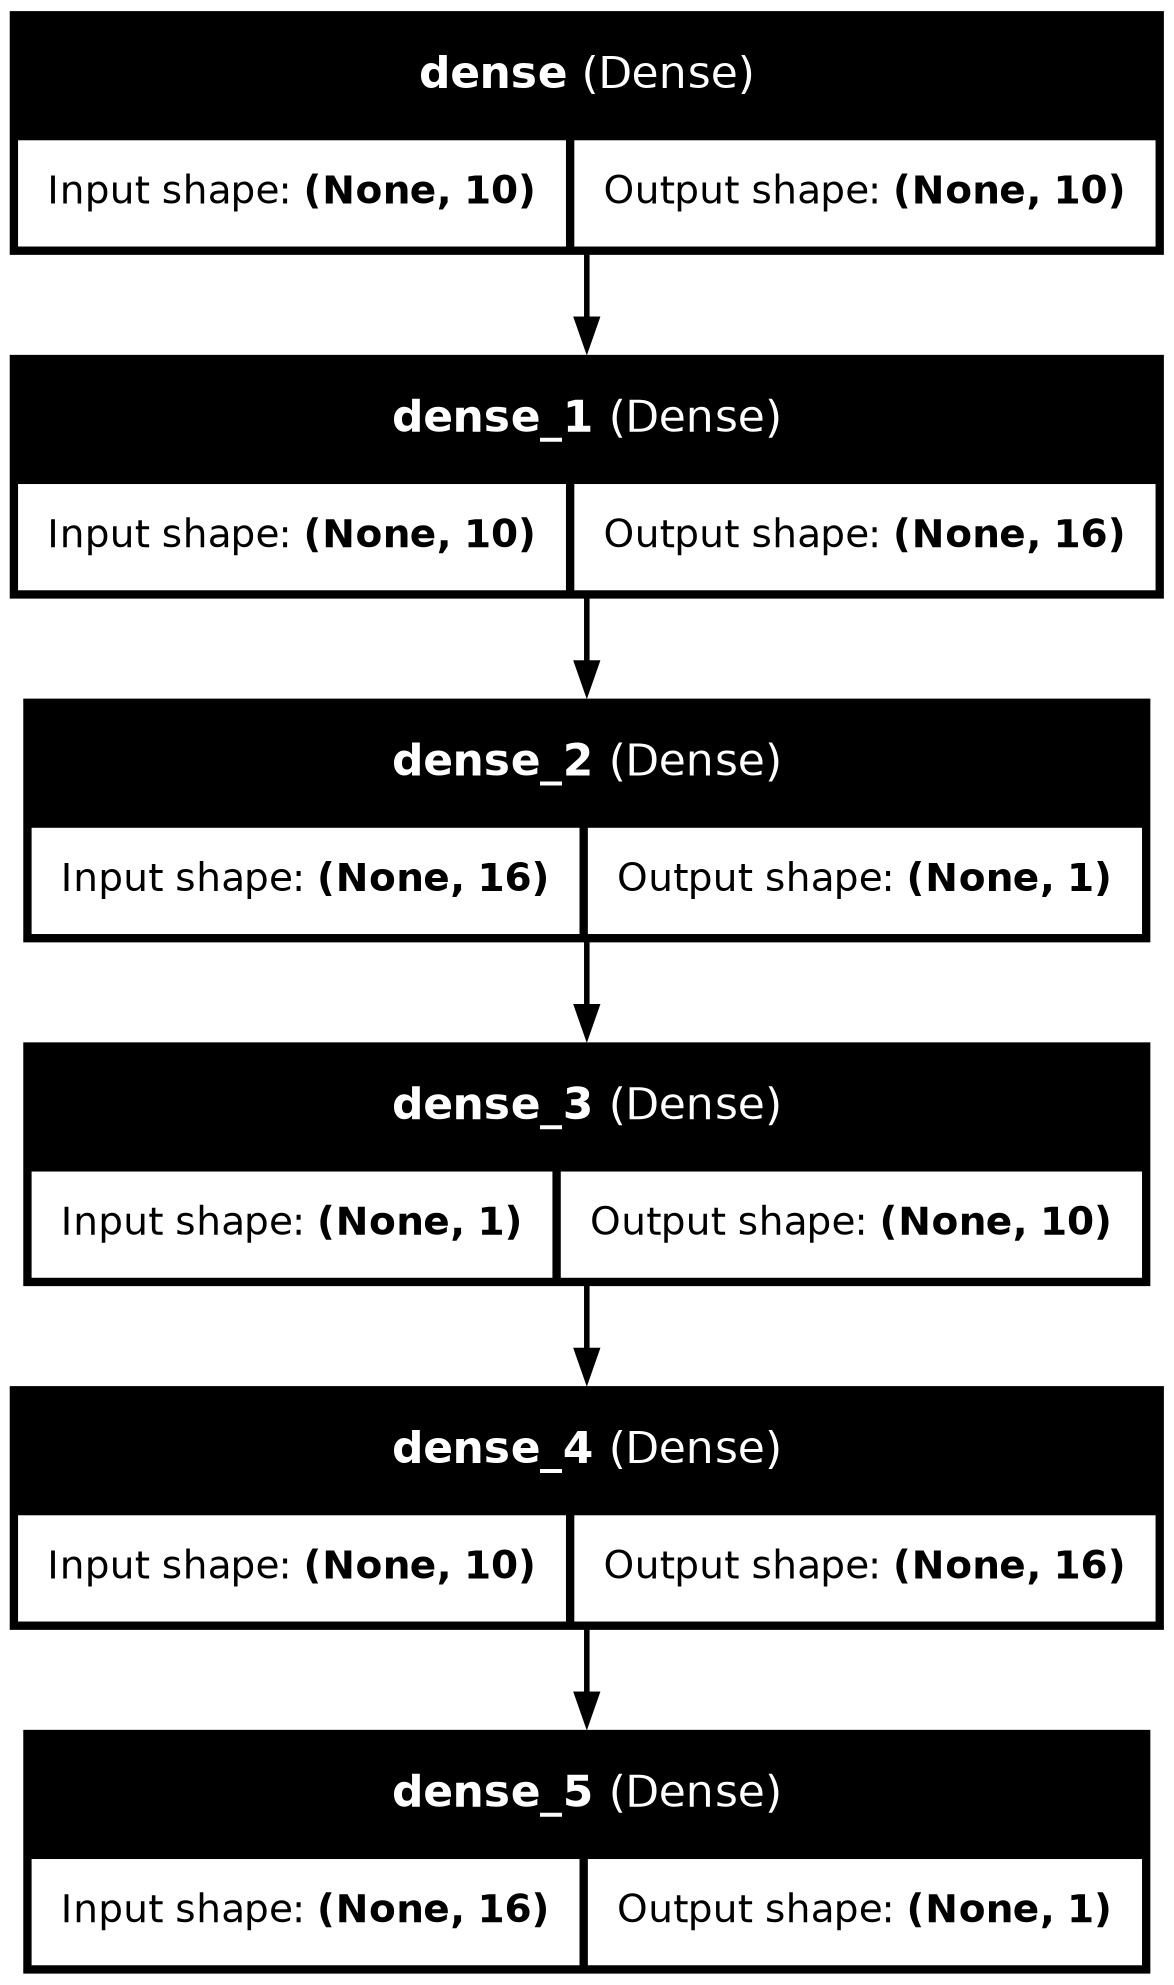

In [9]:
# Adding the input layer and the first hidden layer
model.add(Dense(units = 10, kernel_initializer = 'uniform', activation = 'relu', input_dim = 10))

# Adding the second hidden layer
model.add(Dense(units = 16, kernel_initializer = 'uniform', activation = 'relu'))

# Adding the output layer
model.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'sigmoid'))

# Compiling the ANN
model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

In [10]:
# Fitting the Neural Network to the Training set
model.fit(X_train, y_train, batch_size = 10, epochs = 100)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5025 - loss: 0.6931
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5575 - loss: 0.6924
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5575 - loss: 0.6917
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5575 - loss: 0.6910
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5575 - loss: 0.6903
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5575 - loss: 0.6897
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5575 - loss: 0.6890
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5575 - loss: 0.6882
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5575 - loss: 0.6868
Epoch 10/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5575 - loss: 0.6856
Epoch 11/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5575 - loss: 0.6841
Epoch 12/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy:

# Task

We would create a dataset for you with 20 input features and 2 output classes. Your task is to design a neural network with an input layer, 2 hidden layers with 32 neurons and an output layer that can classify into 2 classes.

In [11]:
#Creating the dataset
X, y = make_classification(n_samples = 500,
                                       n_features = 20,
                                       n_informative = 5,
                                       n_redundant = 0,
                                       n_classes = 2,
                                       weights = [.3, .421])

In [13]:
#your code here
model2 = Sequential()
model2.add(Dense(units = 10, kernel_initializer = 'uniform', activation = 'relu', input_dim = 20))
model2.add(Dense(units = 32, kernel_initializer = 'uniform', activation = 'relu'))
model2.add(Dense(units = 32, kernel_initializer = 'uniform', activation = 'relu'))
model2.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'sigmoid'))
model2.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])


# Activation functions

- Helps the artificial neural network learn complex patterns in the data 

- input into the activation function is W*x + b where W is the weights of the cell and the x is the inputs and then there is the bias b added to that. This value if not restricted to a certain limit can go very high in magnitude 

- ability to add non-linearity into a neural network.

![Activation Function](https://miro.medium.com/max/1200/1*ZafDv3VUm60Eh10OeJu1vw.png)

![Activation Function](http://rasbt.github.io/mlxtend/user_guide/general_concepts/activation-functions_files/activation-functions.png)

Also see: https://www.youtube.com/watch?v=SXrXUqDjICA

# Learning Rate

- The learning rate is a hyperparameter that controls how much to change the model in response to the estimated error each time the model weights are updated 

- a value of learning rate too small may result in a long training process that could get stuck 

- a value of learning rate too large may result in not obtaining optimal parameter values

![LR](https://www.jeremyjordan.me/content/images/2018/02/Screen-Shot-2018-02-24-at-11.47.09-AM.png)

In [14]:
X, y = make_classification(n_samples = 500,
                                       n_features = 15,
                                       n_informative = 5,
                                       n_redundant = 0,
                                       n_classes = 2,
                                       weights = [.3, .421])

In [15]:
#Let's make a neural network here:
model3 = Sequential()
model3.add(Dense(units = 10, kernel_initializer = 'uniform', activation = 'relu', input_dim = 15))
model3.add(Dense(units = 32, kernel_initializer = 'uniform', activation = 'relu'))
model3.add(Dense(units = 32, kernel_initializer = 'uniform', activation = 'relu'))
model3.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'sigmoid'))
model3.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])


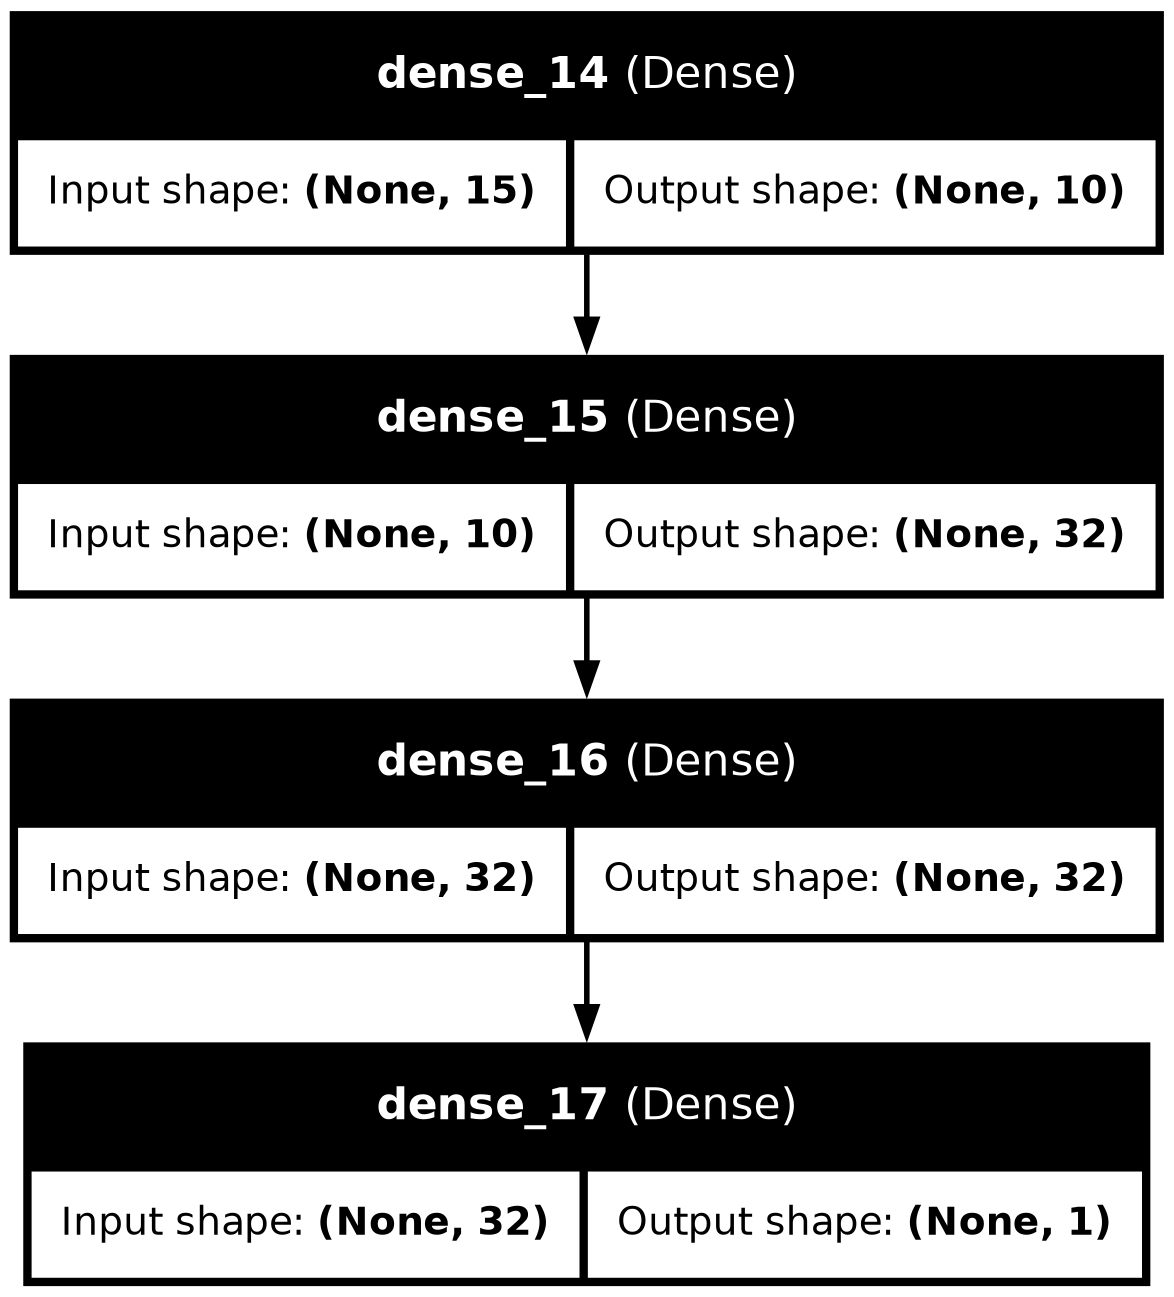

In [16]:
#Let's see how it looks like
plot_model(model3, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

Now, make the following modifications to the model: 'model3'

- Change the activation functions to tanh (apart from last layer)

- Add 2 more layers after the input layer with 24 and 48 neurons

- Change the learning rate to SGD, RMSprop

Visulaize the neural network at every step.

/home/nate/venvs/nlp/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


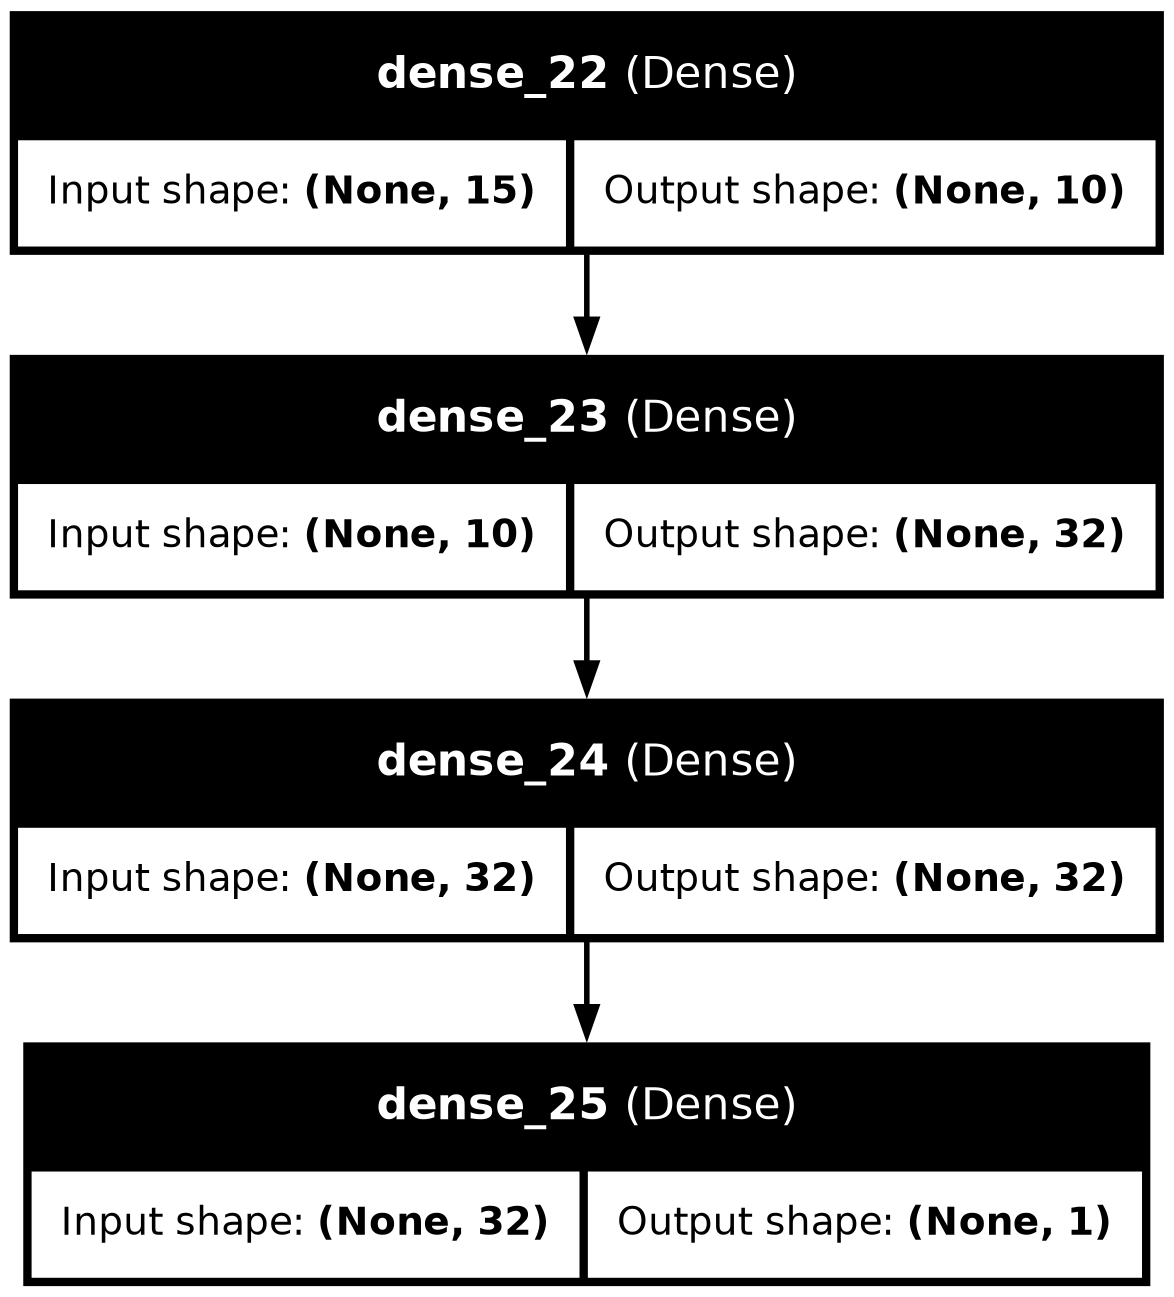

In [18]:
#change activation functions to tanh
#your code here
model3 = Sequential()
model3.add(Dense(units = 10, kernel_initializer = 'uniform', activation = 'tanh', input_dim = 15))
model3.add(Dense(units = 32, kernel_initializer = 'uniform', activation = 'tanh'))
model3.add(Dense(units = 32, kernel_initializer = 'uniform', activation = 'tanh'))
model3.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'sigmoid'))
model3.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
plot_model(model3, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

/home/nate/venvs/nlp/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


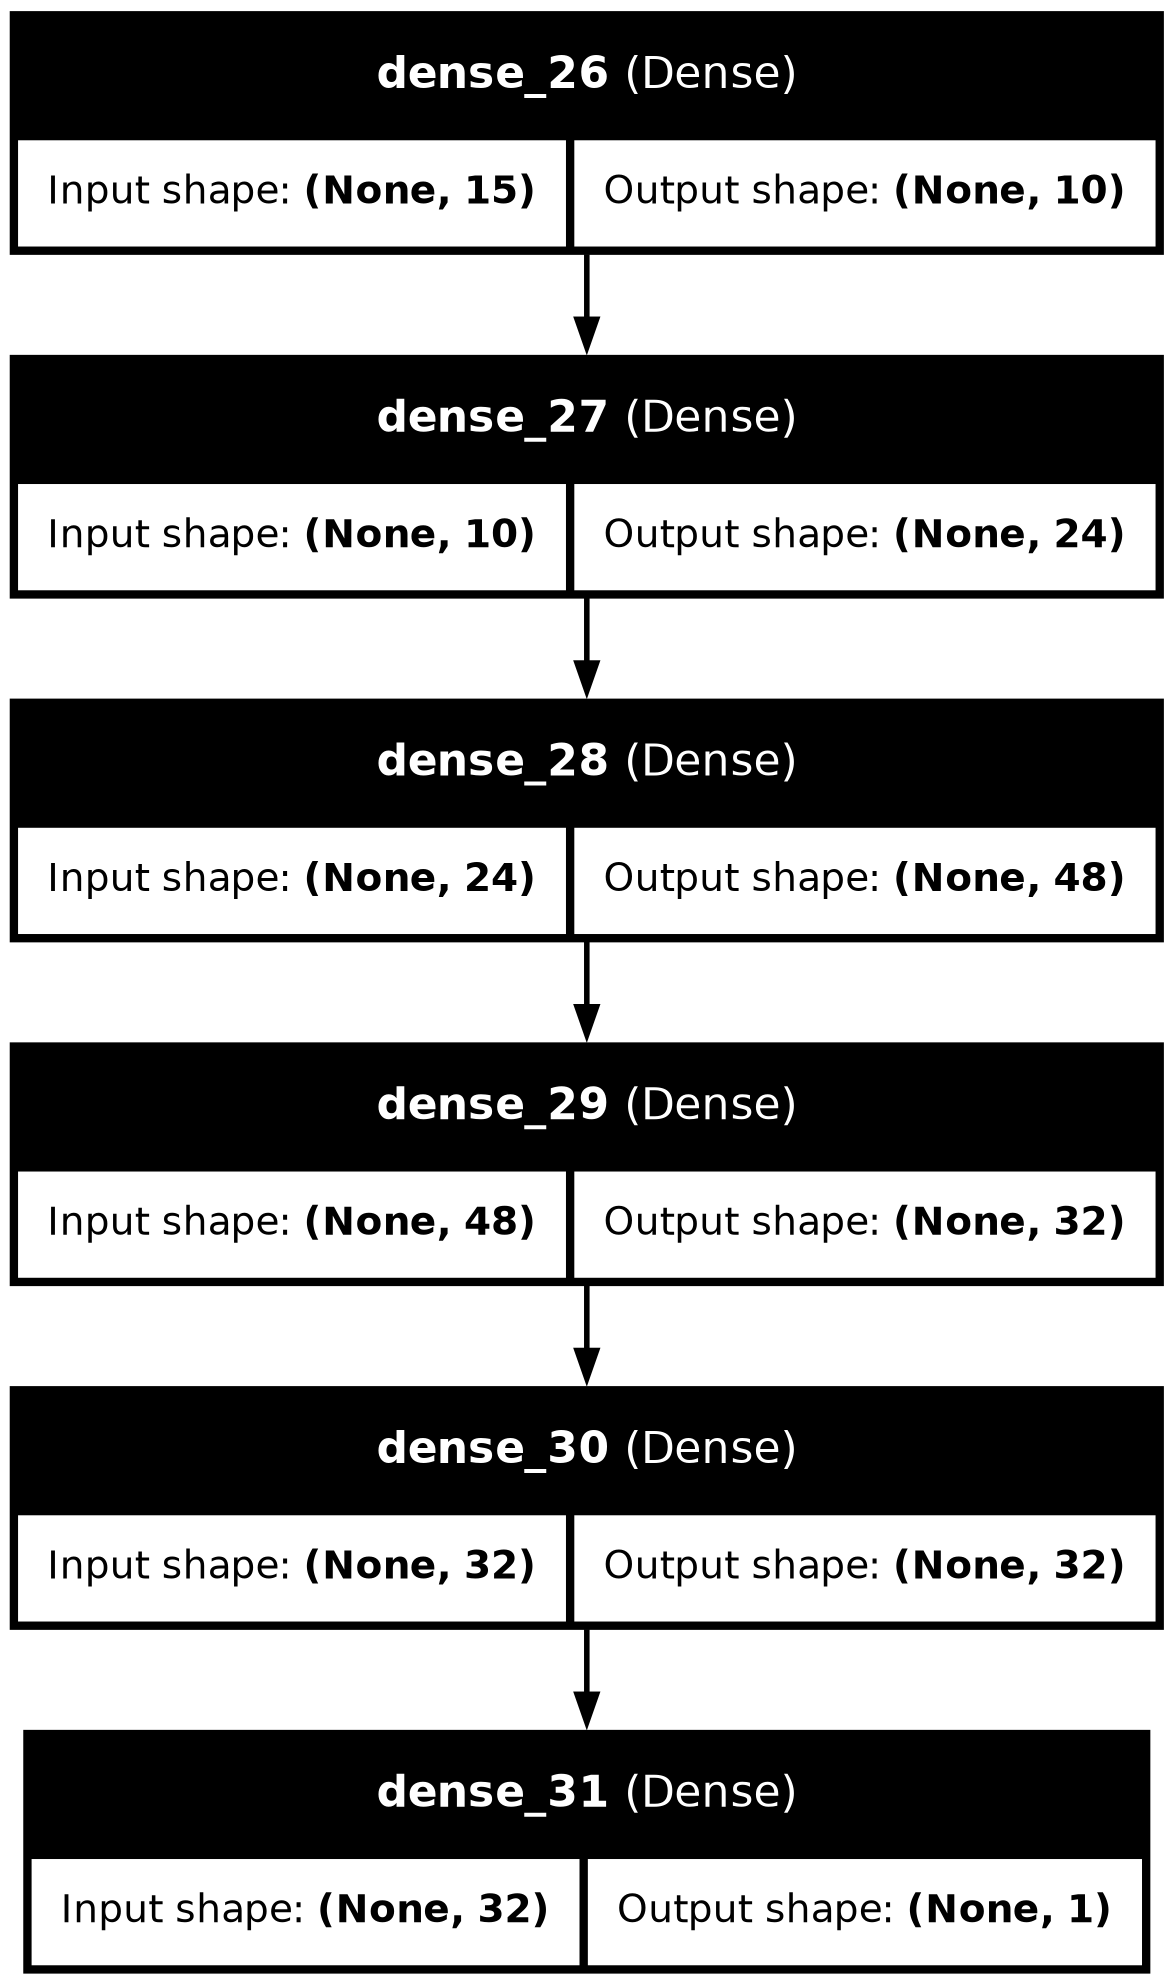

In [19]:
#add layers after input layer
#your code here
model3 = Sequential()
model3.add(Dense(units = 10, kernel_initializer = 'uniform', activation = 'tanh', input_dim = 15))
model3.add(Dense(units = 24, kernel_initializer = 'uniform', activation = 'tanh'))
model3.add(Dense(units = 48, kernel_initializer = 'uniform', activation = 'tanh'))
model3.add(Dense(units = 32, kernel_initializer = 'uniform', activation = 'tanh'))
model3.add(Dense(units = 32, kernel_initializer = 'uniform', activation = 'tanh'))
model3.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'sigmoid'))
model3.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
plot_model(model3, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

/home/nate/venvs/nlp/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


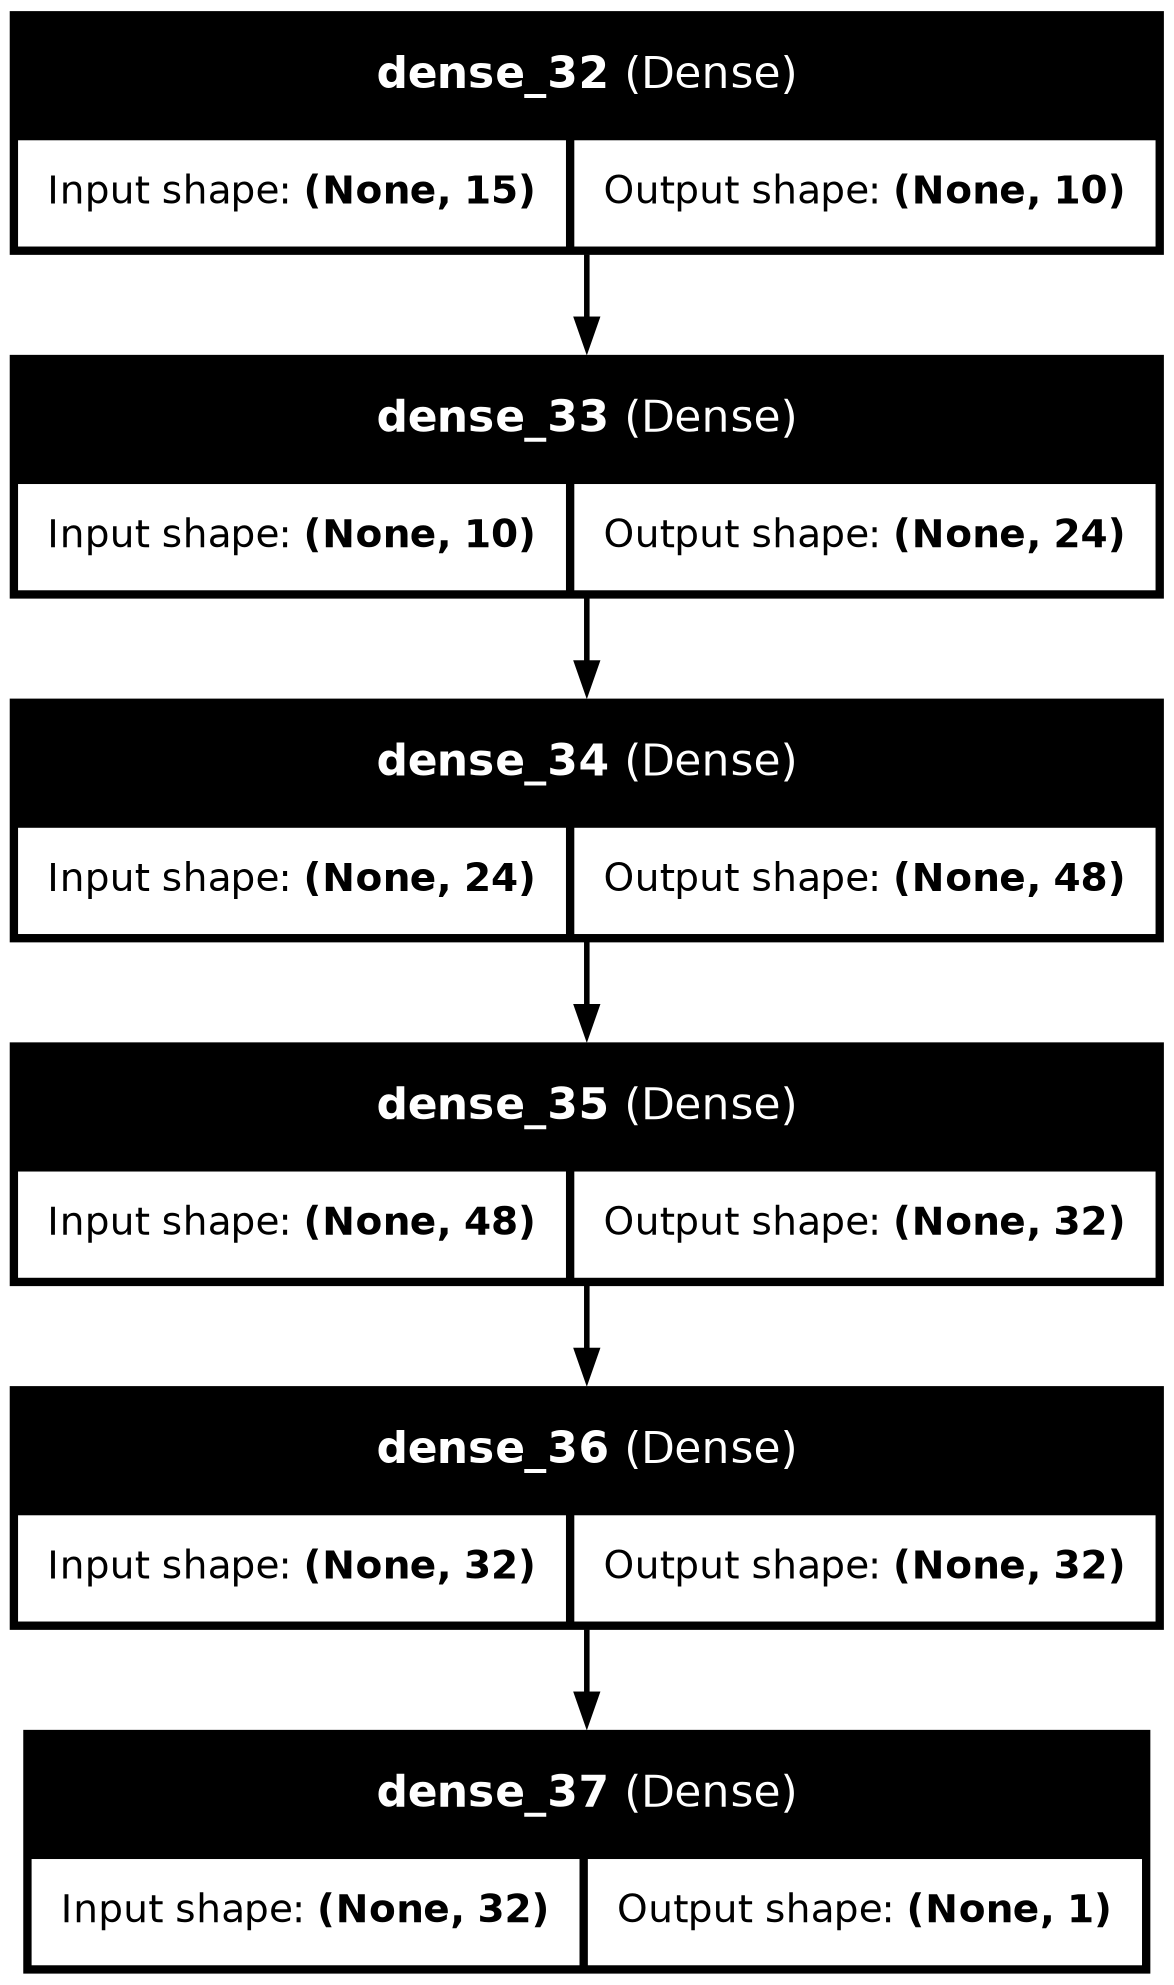

In [20]:
#change optimizer to SGD
#your code here
model3 = Sequential()
model3.add(Dense(units = 10, kernel_initializer = 'uniform', activation = 'tanh', input_dim = 15))
model3.add(Dense(units = 24, kernel_initializer = 'uniform', activation = 'tanh'))
model3.add(Dense(units = 48, kernel_initializer = 'uniform', activation = 'tanh'))
model3.add(Dense(units = 32, kernel_initializer = 'uniform', activation = 'tanh'))
model3.add(Dense(units = 32, kernel_initializer = 'uniform', activation = 'tanh'))
model3.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'sigmoid'))
model3.compile(optimizer = 'SGD', loss = 'binary_crossentropy', metrics = ['accuracy'])
plot_model(model3, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

/home/nate/venvs/nlp/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


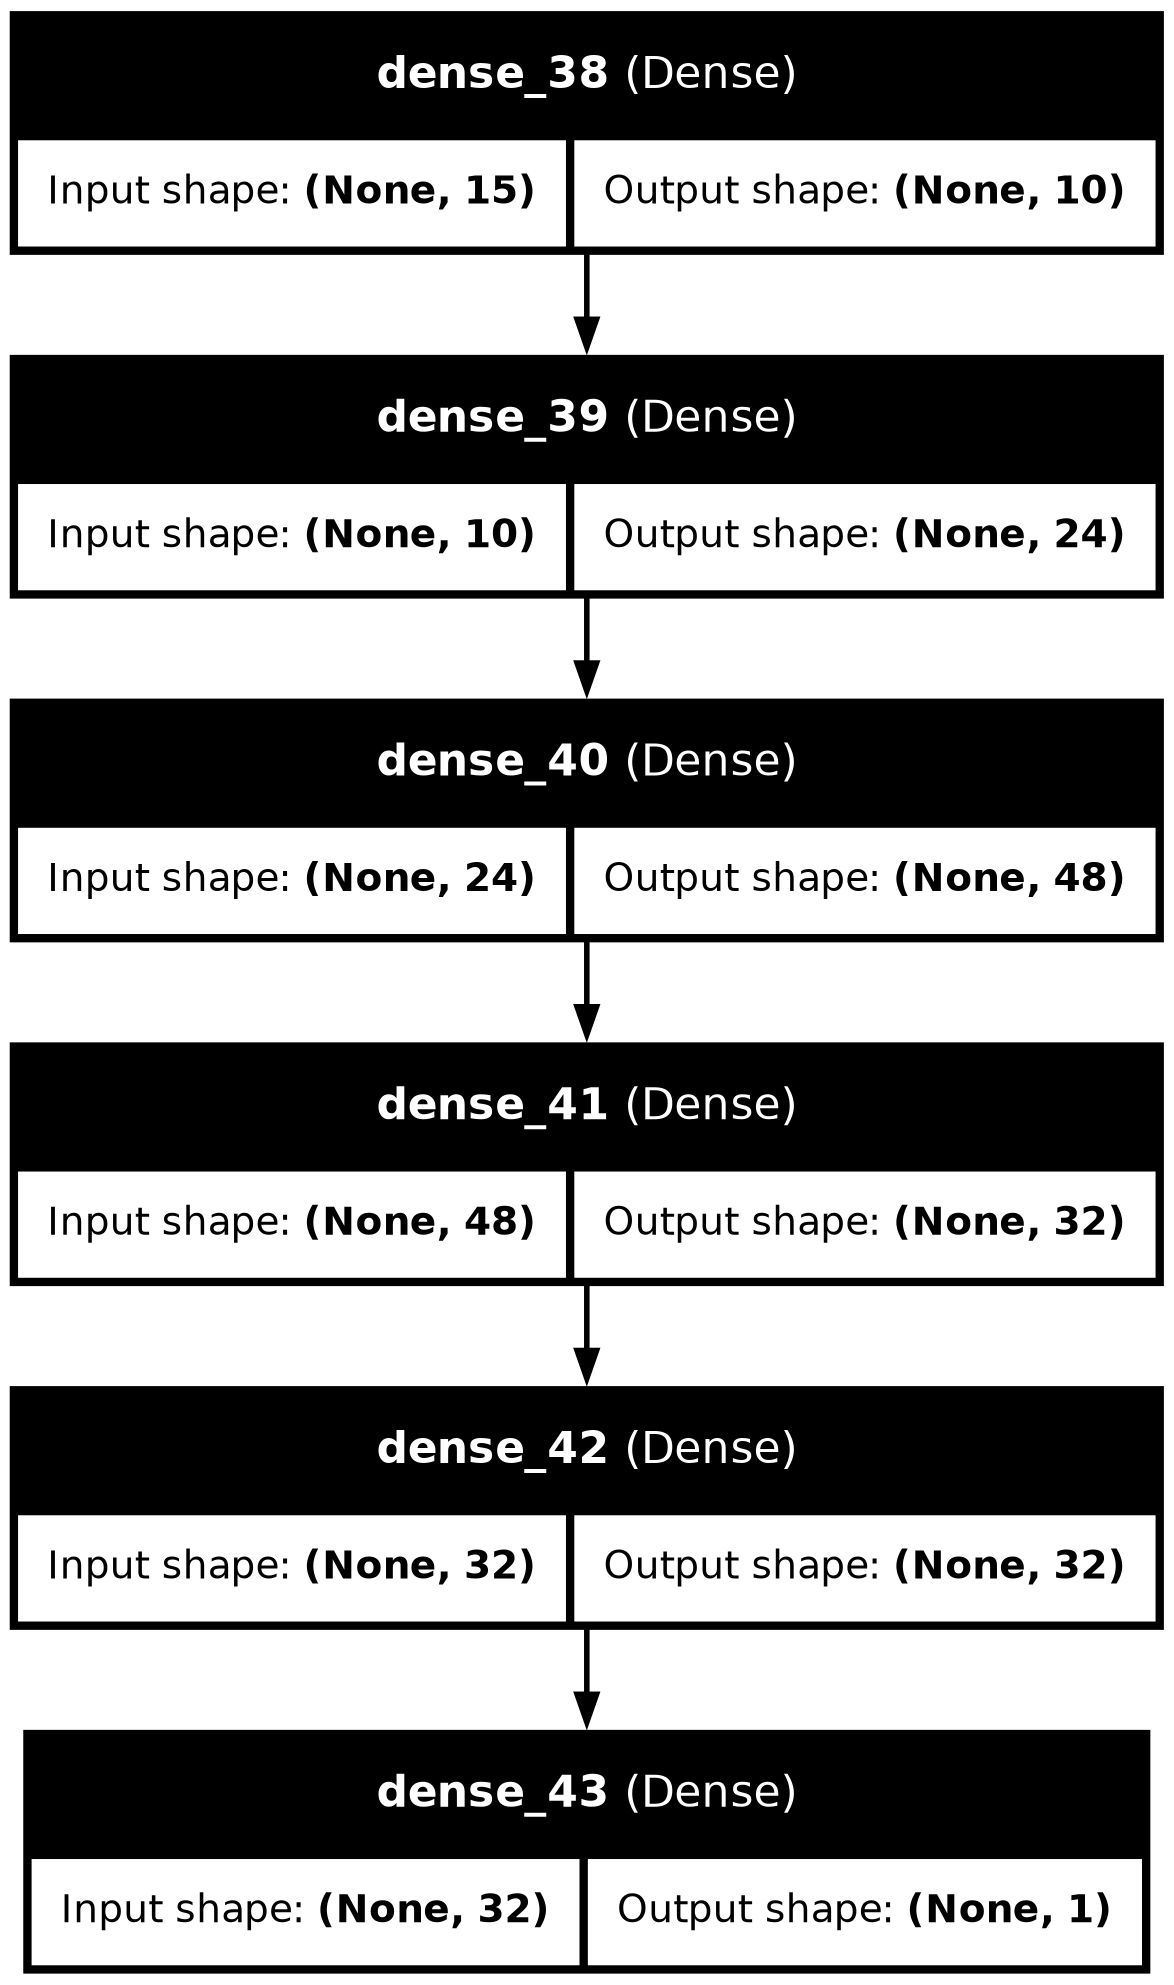

In [21]:
#change optimizer to RMSprop
#your code here
model3 = Sequential()
model3.add(Dense(units = 10, kernel_initializer = 'uniform', activation = 'tanh', input_dim = 15))
model3.add(Dense(units = 24, kernel_initializer = 'uniform', activation = 'tanh'))
model3.add(Dense(units = 48, kernel_initializer = 'uniform', activation = 'tanh'))
model3.add(Dense(units = 32, kernel_initializer = 'uniform', activation = 'tanh'))
model3.add(Dense(units = 32, kernel_initializer = 'uniform', activation = 'tanh'))
model3.add(Dense(units = 1, kernel_initializer = 'uniform', activation = 'sigmoid'))
model3.compile(optimizer = 'RMSprop', loss = 'binary_crossentropy', metrics = ['accuracy'])
plot_model(model3, to_file='model_plot.png', show_shapes=True, show_layer_names=True)

## Submission Instructions

    Complete all TensorFlow Playground experiments
    
    Run and modify all required code sections
    
    Answer all questions in markdown cells
    
    Export the notebook as HTML:
    
        File → Download as → HTML (.html)
    
    Submit the HTML file in Canvas by the posted deadline

## Part 1: TensorFlow Playground Exploration (40 points)
Complete Outside the Notebook

    Go to:
    https://playground.tensorflow.org/Links to an external site.
    mm
    Follow the steps below exactly.

    Configuration
        Set the following parameters:

            Hidden layers: 3
            
            Activation function: Sigmoid
            
            Ratio of training to test data: 80% (0.8)

    Datasets
        Run experiments on each dataset one at a time:

            Circle
            
            XOR
            
            Gauss
            
            Spiral

        For each dataset:

            Start training using the play button
            
            Hover over neurons in the hidden layers to observe their outputs
            
            Observe how quickly the model converges
            
            Note the final test loss



Building Neural Networks in Code (40 points)
In this section, you will implement in code what you explored visually.

Tasks (Answer in Markdown Cells)

    1. Run the model with the current setup (three hidden layers, sigmoid). How do the results compare to TensorFlow Playground?

    2. Change all activation functions to ReLU and retrain. Does the model learn faster or achieve better performance?

    3. Reduce the network to one hidden layer with eight neurons. Does performance drop? Why?

    4. Try overfitting by using five hidden layers with sixteen neurons each. What happens to validation loss and accuracy?





    1. Run the model with the current setup (three hidden layers, sigmoid). How do the results compare to TensorFlow Playground?
       For convergence being defined as a desired point within the models gradient which is where the ideal soultion is found for prediciting classificiton labels I will then looks towards the output graph as the aggratate of those neurons & their connections with weights to see it's point of convergening on that solution.

       For the model within my current setup I don't have such a live, aggrate view of the convergenceo of the model so I'll have to use something else. What I do have though are two graphs of the training & validation loss & accuracy respectivly along with the test accuracy; so how do these tell me about a models convergence? I recall that loss in general is that of some measure of the model's incorrect predicitons (taking account TP, FP, and all that) where such a value here is gotten in the training set (during the model's run), validation set (once per epoch), and the test set.

       Ideally, all such values of loss are to be very low with accuracy very high, but that's the battle we fight. Going forward I'm going to use such a metric in the playground as well.

       Set-up Model Metrics for fifty epochs:
       - Training Loss: 0.673
       - Validation Loss: 0.665 
       - Training Accuracy: 0.5980
       - Validation Accuracy: 0.6180
       - Test Accuracy: 0.595
         
       Tensor Playground Metrics for fifty epochs on each datset:
       - Circle  
        Test Loss: 0.513  
        Training Loss: 0.502
        
       - XOR
        Test Loss: 0.508  
        Training Loss: 0.499

       - Gauss
        Test Loss: 0.500 
        Training Loss: 0.501

       - Spiral
        Test Loss: 0.501 
        Training Loss: 0.501

       Though this is split between dataset types, it seems that the similer model created inn TensorPlayground achives lower Training & Test Loss then my model does here. Looking over the model within the notebook, it seems to have a greater amont of neurons within the second & third layer which make up it's hidden layers; conversely the TensorflowPlayground has a smaller amount being four & two within the repsective hidden layers.
       - How would that make a difference here?    

         
    2. Change all activation functions to ReLU and retrain. Does the model learn faster or achieve better performance?
       All listed are following the change of activation function ran with the listed epochs

       Set-up Model Metrics for fifty epochs:
       - Training Loss: 0.15
       - Validation Loss: 0.1 
       - Training Accuracy: 0.098
       - Validation Accuracy: 1
       - Test Accuracy: 0.970
         
       Tensor Playground Metrics for fifty epochs on each datset:
       - Circle  
        Test Loss: 0.003 
        Training Loss: 0.003
        
       - XOR
        Test Loss: 0.003  
        Training Loss: 0.003

       - Gauss
        Test Loss: 0.000 
        Training Loss: 0.000

       - Spiral
        Test Loss: 0.480 
        Training Loss: 0.472

        Both sorts of models trained & tested show similer improvements accross the board, besides that of Spiral; for some reason this sort of database stands in the way of being the 'best' activation function to use. Besides that, the validation accuracy for the notebook model and likely the TensorFlow model using TensorflowPlayground is of one while also having improvment in the loss of both the training & test loss while increasing in training accuracy, meaning it's likely not to be a case of overfitting but real generalizablity of the model.
        - Why is it that the spiral database is a challange for the ReLu activation function.

          The reason for this is sort of a cascading one. The spiral database although basic is a great non-linear space of information; this can translate to needing a large cover of the area of a gradient to find a ideal solution. Moving onto ReLU, it's an activation funciton which will output zero for half of it's domain, so sometimes an argument 'x' passed can cause it to equal zero; such a zero is to be the weight sum of that argument plus a baic-- so notice here now I'm venturing into the process of the model going through it's solution search: I digrease.

          Such an acitvation function like ReLU due to being zero for half it's domain can cause neurons to make their weight zero which means it can no longer be used by the network due to the function becoming flat for all negative numbers so no more weight changes for search can be used. I might say now that such a dying neuron is the point, and it is, but with such a small amount of neurons in the network such an activation function will kill the complete network: this is what I what I was noticing for the spiral dataset.
          

    3. Reduce the network to one hidden layer with eight neurons. Does performance drop? Why?
       All listed are following the above request with fifty epochs still and with the activation function of ReLU.

        Set-up Model Metrics for fifty epochs:
       - Training Loss: 0.1
       - Validation Loss: 0.1 
       - Training Accuracy: 0.98
       - Validation Accuracy: 0.98
       - Test Accuracy: 0.955
         
       Tensor Playground Metrics for fifty epochs on each datset:
       - Circle  
        Test Loss: 0.010 
        Training Loss: 0.012
        
       - XOR
        Test Loss: 0.009  
        Training Loss: 0.005

       - Gauss
        Test Loss: 0.000 
        Training Loss: 0.000

       - Spiral
        Test Loss: 0.463 
        Training Loss: 0.459

        Interesting enough preformance does drop but not by much while conversly the tensflow model on the spiral dataset increase in preformance a bit.
        - So why is it that dropping the hidden lay to a larger but single stack of neurons leads to similer preformance as it being distirbuted over two layers when using ReLU?

          Answering this requires me to think about the different structure of the prior model & this one here. To begin with, this is generally an increase of neurons then the last, which means that there is less of a chance that the network was totally killed by ReLU. Another thing to point out is that this model has low capcaity, where capcity here is to be the ablity of a model to capture underlying meaning from data; visually such a network like this one will have a few amount of interconneting lines or decision boundaires, pointing to it's real geometric sign of being too simple or having too much archutexutal simplicty to model the complex space of the data. In terms of preformance this means that the model did converge but only in terms of it's capacity rather then any other possible factor.
          


    4. Try overfitting by using five hidden layers with sixteen neurons each. What happens to validation loss and accuracy?
       Due to a limit in TensflowPlayground I cannot use 16 neurons but rather only eight per layer, so I won't be using it here. Again with fifty Epochs & ReLU activation.

       Set-up Model Metrics:
       - Training Loss: 6.5
       - Validation Loss: 9.0 
       - Training Accuracy: 0.60
       - Validation Accuracy: 0.50
       - Test Accuracy: 0.620

         As can be seen, both the validation loss & accuracy shoot up in value as relativly large interger values which is indicated of model underpreformance: interesting enough the accuracy for training isn't that high so the model isn't wholly learning too much of the dataset. Connecting it with above this might be the model reaching it's capacity but in greater network design rather then amount of neurons or weight distribution.
       
*

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import plot_model
import plotly.io as pio
pio.renderers.default = "svg"

print("TensorFlow version:", tf.__version__)

2026-02-28 17:17:02.117618: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/nate/venvs/nlp/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow version: 2.20.0


In [2]:
### Simple Binary Classification (Circle / XOR-like Data)
# Generate circle-like data
def generate_circle_data(n=500):
    X = np.random.rand(n, 2) * 2 - 1
    y = (X[:,0]**2 + X[:,1]**2 < 0.5).astype(int)
    return X, y

X, y = generate_circle_data(1000)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
### Build the Model
model = Sequential([
    Dense(8, activation='relu', input_shape=(2,)),
    Dense(16, activation='relu'),
    Dense(16, activation='relu'),
    Dense(16, activation='relu'),
    Dense(16, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='relu')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,273 (4.97 KB)

 Trainable params: 1,273 (4.97 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
### Train the Model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2,
    verbose=0
)

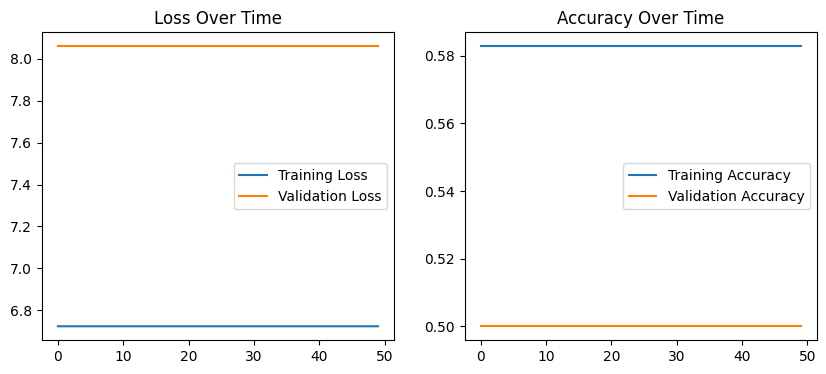

In [18]:
### Visualize Training
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Time')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Time')
plt.legend()

plt.show()

In [19]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.3f}")

Test Accuracy: 0.620
